Import Libraries, Load Dataset, and Understand the Data

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Dataset
# Load the CSV dataset into a pandas DataFrame
df = pd.read_csv("Telco-Customer-Churn.csv")

# Display the first 5 rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check Dataset Shape

# Display the number of rows and columns
print("Dataset Shape:", df.shape)

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (7043, 21)
Number of Rows: 7043
Number of Columns: 21


In [5]:
# Display Column Names

# Display all column names in the dataset
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
# Step 5: Check Dataset Information

# Display information about columns, data types,and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Check Missing Values

# Count missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Check Duplicate Records

# Count the number of duplicate rows
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [9]:
# Statistical Summary

# Display statistical summary of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Data Cleaning and Preparation.

In [10]:
# Check Unique Values in Target Column

# Display unique values in the Churn column
print(df["Churn"].unique())

# Count customers in each churn category
print(df["Churn"].value_counts())

['No' 'Yes']
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [11]:
# Check Blank Values in TotalCharges

# Count blank/empty space values in TotalCharges
blank_values = (df["TotalCharges"].str.strip() == "").sum()

print("Blank values in TotalCharges:", blank_values)

Blank values in TotalCharges: 11


In [12]:
# Convert TotalCharges to Numeric

# Convert TotalCharges from object to numeric
# Invalid or blank values will be converted to NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check the data type after conversion
print(df["TotalCharges"].dtype)

float64


In [13]:
# Check Missing Values After Conversion

# Display missing values in each column
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
# Remove Missing Values

# Remove rows containing missing values
df.dropna(inplace=True)

# Reset the DataFrame index
df.reset_index(drop=True, inplace=True)

# Check dataset shape after removing missing values
print("Dataset Shape:", df.shape)

Dataset Shape: (7032, 21)


In [15]:
# Remove Unnecessary Column

# Remove customerID because it is not useful for prediction
df.drop("customerID", axis=1, inplace=True)

# Display first 5 rows
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
# Verify Cleaned Dataset

# Display dataset information
df.info()

# Check missing values
print("\nTotal Missing Values:", df.isnull().sum().sum())

# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Display dataset shape
print("Final Dataset Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 


In [17]:
# View Duplicate Rows

# Display all duplicate rows
duplicate_rows = df[df.duplicated()]

print("Number of Duplicate Rows:", duplicate_rows.shape[0])

duplicate_rows

Number of Duplicate Rows: 22


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
961,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
1334,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
1486,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1734,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90,Yes
1927,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,No
2708,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
2887,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.45,20.45,No
3296,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.60,Yes
3748,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
4091,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.20,20.20,Yes


In [18]:
# Remove Duplicate Rows

# Remove duplicate rows from the dataset
df.drop_duplicates(inplace=True)

# Reset the index
df.reset_index(drop=True, inplace=True)

# Display final dataset shape
print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (7010, 20)


In [19]:
# Final Data Cleaning Check

print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Final Dataset Shape:", df.shape)

Total Missing Values: 0
Duplicate Rows: 0
Final Dataset Shape: (7010, 20)


Exploratory Data Analysis (EDA)

In [20]:
# Analyze Churn Distribution

# Count the number of customers in each churn category
print(df["Churn"].value_counts())

# Display churn percentage
print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5153
Yes    1857
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.509272
Yes    26.490728
Name: proportion, dtype: float64


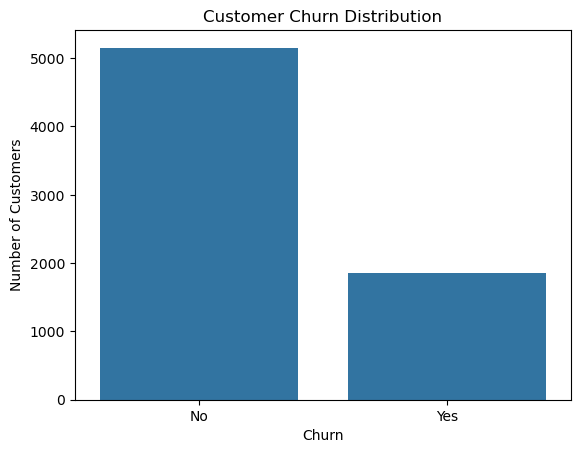

In [21]:
# Visualize Churn Distribution

# Create a count plot for the Churn column
sns.countplot(x="Churn", data=df)

# Add chart title and labels
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

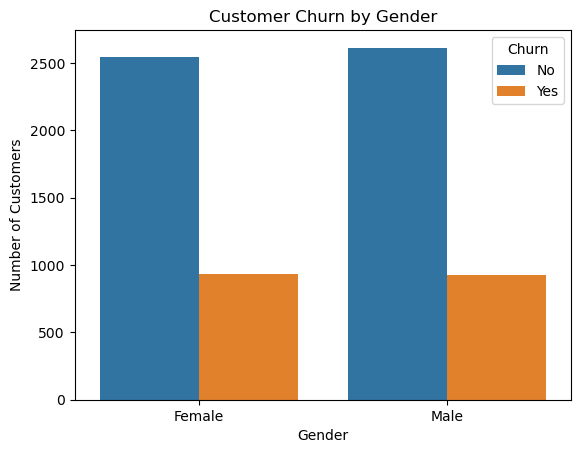

In [22]:
# Analyze Churn by Gender

# Create a count plot of Gender grouped by Churn
sns.countplot(x="gender", hue="Churn", data=df)

# Add chart title and labels
plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

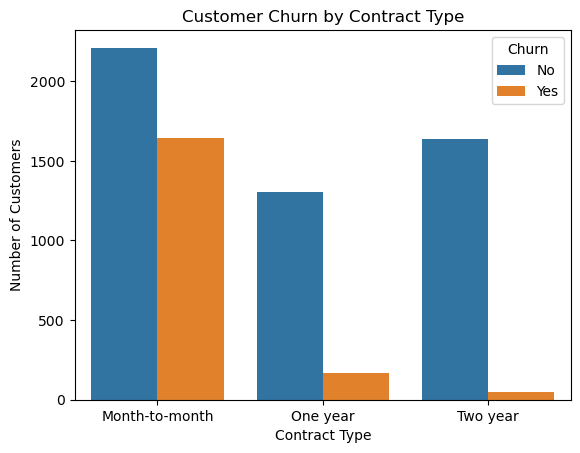

In [23]:
# Analyze Churn by Contract Type

# Create a count plot of Contract grouped by Churn
sns.countplot(x="Contract", hue="Churn", data=df)

# Add chart title and labels
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

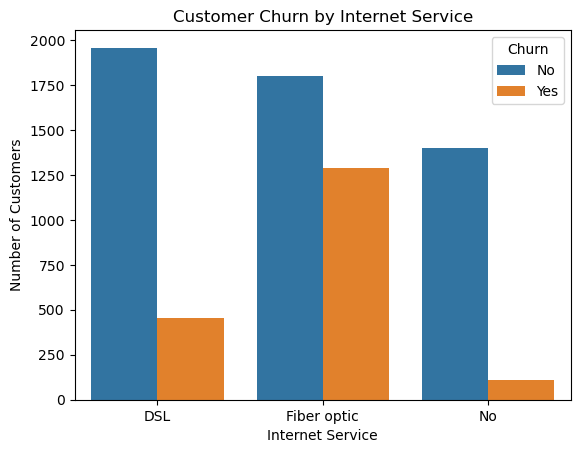

In [24]:
# Analyze Churn by Internet Service

# Create a count plot of Internet Service grouped by Churn
sns.countplot(x="InternetService", hue="Churn", data=df)

# Add chart title and labels
plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

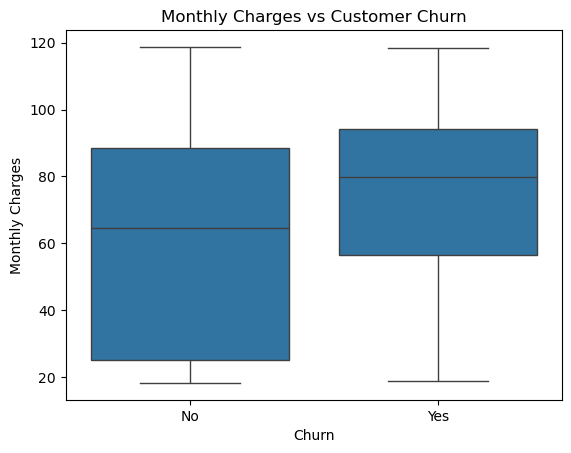

In [25]:
# Analyze Monthly Charges by Churn

# Create a box plot to compare Monthly Charges with Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

# Add chart title and labels
plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

# Display the chart
plt.show()

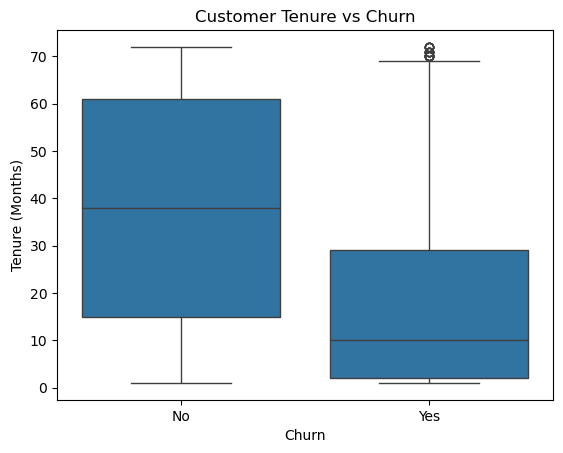

In [26]:
# Analyze Tenure by Churn

# Create a box plot to compare Tenure with Churn
sns.boxplot(x="Churn", y="tenure", data=df)

# Add chart title and labels
plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

# Display the chart
plt.show()

In [27]:
# Compare Numerical Features by Churn

# Calculate the average numerical values
# for each Churn category
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.721133,61.387415,2560.264118
Yes,18.088853,74.604308,1541.376548


Data Preprocessing for Machine Learning

In [28]:
# Check Categorical Columns

# Select all columns with object data type
categorical_columns = df.select_dtypes(include=["object"]).columns

# Display categorical columns
print("Categorical Columns:")
print(categorical_columns)

# Display total number of categorical columns
print("\nTotal Categorical Columns:", len(categorical_columns))

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

Total Categorical Columns: 16


In [29]:
# Check Unique Values in Categorical Columns

# Display unique values of each categorical column
for column in categorical_columns:
    print(column, ":", df[column].unique())

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


In [30]:
# Encode Target Column

# Convert Churn values into numerical values
# No = 0 (Customer Stayed)
# Yes = 1 (Customer Churned)

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Check the result
print(df["Churn"].value_counts())

Churn
0    5153
1    1857
Name: count, dtype: int64


In [31]:
# Separate Features and Target

# X contains all input features
X = df.drop("Churn", axis=1)

# y contains the target variable
y = df["Churn"]

# Display shapes
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7010, 19)
y Shape: (7010,)


In [32]:
# Encode Categorical Features

# Convert categorical features into numerical dummy variables
X = pd.get_dummies(X, drop_first=True, dtype=int)

# Display first 5 rows after encoding
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [33]:
# Check Encoded Dataset

# Display dataset shape after encoding
print("X Shape After Encoding:", X.shape)

# Display data types
print("\nData Types:")
print(X.dtypes)

# Check if any categorical columns remain
print("\nRemaining Object Columns:", X.select_dtypes(include=["object"]).columns.tolist())

X Shape After Encoding: (7010, 30)

Data Types:
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes      

Train-Test Split

In [34]:
# Split Dataset into Training and Testing Sets

# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (5608, 30)
X_test Shape: (1402, 30)
y_train Shape: (5608,)
y_test Shape: (1402,)


Feature Scaling

In [35]:
# Scale the Features

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Display shapes
print("Scaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape:", X_test_scaled.shape)

Scaled Training Data Shape: (5608, 30)
Scaled Testing Data Shape: (1402, 30)


Build and Evaluate the First ML Model

In [36]:
# Import Logistic Regression

# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression()

# Display the model
logistic_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
# Train Logistic Regression Model

# Train the model using training data
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [38]:
# Make Predictions on Test Data

# Predict Churn for testing data
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Display first 10 predicted values
print("First 10 Predictions:")
print(y_pred_logistic[:10])

# Display first 10 actual values
print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 Actual Values:
[0 0 0 0 0 1 0 0 0 0]


In [43]:
# Calculate Model Accuracy

# Import accuracy_score
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy)

# Display accuracy as percentage
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Logistic Regression Accuracy: 0.8088445078459344
Accuracy Percentage: 80.88 %


In [40]:
# Display Classification Report

# Import classification_report
from sklearn.metrics import classification_report

# Display classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["No Churn", "Churn"]
    )
)

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.91      0.87      1031
       Churn       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402



In [41]:
# Create Confusion Matrix

# Import confusion_matrix
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_logistic)

# Display confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[934  97]
 [171 200]]


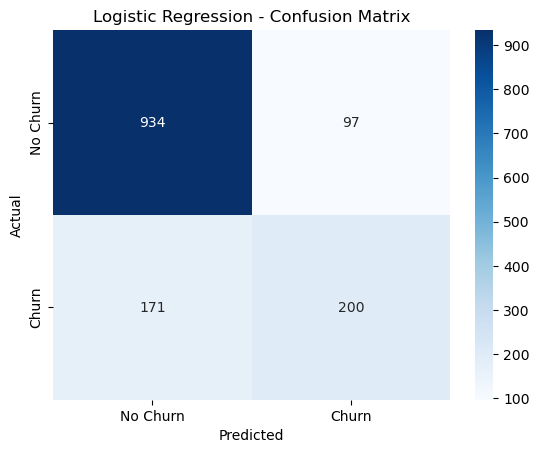

In [42]:
# Visualize Confusion Matrix

# Create a heatmap of the confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

# Add title and labels
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Display the chart
plt.show()

second model: Decision Tree

In [44]:
# Create and Train Decision Tree Model

# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
# Decision Trees do not require scaled features
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [45]:
# Make Predictions Using Decision Tree

# Predict Churn for testing data
y_pred_tree = decision_tree_model.predict(X_test)

# Display first 10 predictions
print("First 10 Predictions:")
print(y_pred_tree[:10])

# Display first 10 actual values
print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

First 10 Predictions:
[1 0 0 0 0 0 0 0 0 0]

First 10 Actual Values:
[0 0 0 0 0 1 0 0 0 0]


In [46]:
# Calculate Decision Tree Accuracy

# Calculate accuracy
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)

print(
    "Accuracy Percentage:",
    round(tree_accuracy * 100, 2),
    "%"
)

Decision Tree Accuracy: 0.7268188302425107
Accuracy Percentage: 72.68 %


In [47]:
# Display Decision Tree Classification Report

print("Decision Tree Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["No Churn", "Churn"]
    )
)

Decision Tree Classification Report:
              precision    recall  f1-score   support

    No Churn       0.81      0.82      0.81      1031
       Churn       0.48      0.48      0.48       371

    accuracy                           0.73      1402
   macro avg       0.65      0.65      0.65      1402
weighted avg       0.73      0.73      0.73      1402



In [48]:
# Create Decision Tree Confusion Matrix

# Calculate confusion matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)

# Display confusion matrix
print("Decision Tree Confusion Matrix:")
print(cm_tree)

Decision Tree Confusion Matrix:
[[842 189]
 [194 177]]


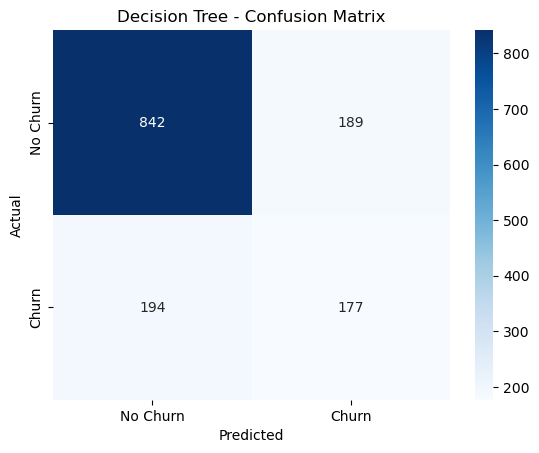

In [49]:
# Visualize Decision Tree Confusion Matrix

# Create heatmap
sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

# Add title and labels
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Display chart
plt.show()

In [50]:
# Check Decision Tree for Overfitting

# Calculate training accuracy
tree_train_accuracy = decision_tree_model.score(
    X_train,
    y_train
)

# Calculate testing accuracy
tree_test_accuracy = decision_tree_model.score(
    X_test,
    y_test
)

print(
    "Training Accuracy:",
    round(tree_train_accuracy * 100, 2),
    "%"
)

print(
    "Testing Accuracy:",
    round(tree_test_accuracy * 100, 2),
    "%"
)

Training Accuracy: 99.8 %
Testing Accuracy: 72.68 %


Train Random Forest Model

In [51]:
# Create and Train Random Forest Model

# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
# Random Forest does not require scaled data
random_forest_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [52]:
# Make Predictions Using Random Forest

# Predict Churn for testing data
y_pred_forest = random_forest_model.predict(X_test)

# Display first 10 predictions
print("First 10 Predictions:")
print(y_pred_forest[:10])

# Display first 10 actual values
print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 Actual Values:
[0 0 0 0 0 1 0 0 0 0]


In [53]:
# ==========================================================
# Step 48: Calculate Random Forest Accuracy
# ==========================================================

# Calculate accuracy
forest_accuracy = accuracy_score(
    y_test,
    y_pred_forest
)

print(
    "Random Forest Accuracy:",
    forest_accuracy
)

print(
    "Accuracy Percentage:",
    round(forest_accuracy * 100, 2),
    "%"
)

Random Forest Accuracy: 0.7895863052781741
Accuracy Percentage: 78.96 %


In [54]:
# Display Random Forest Classification Report

print("Random Forest Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_forest,
        target_names=["No Churn", "Churn"]
    )
)

Random Forest Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1031
       Churn       0.64      0.48      0.55       371

    accuracy                           0.79      1402
   macro avg       0.73      0.69      0.70      1402
weighted avg       0.78      0.79      0.78      1402



In [55]:
# Create Random Forest Confusion Matrix

# Calculate confusion matrix
cm_forest = confusion_matrix(
    y_test,
    y_pred_forest
)

# Display confusion matrix
print("Random Forest Confusion Matrix:")
print(cm_forest)

Random Forest Confusion Matrix:
[[930 101]
 [194 177]]


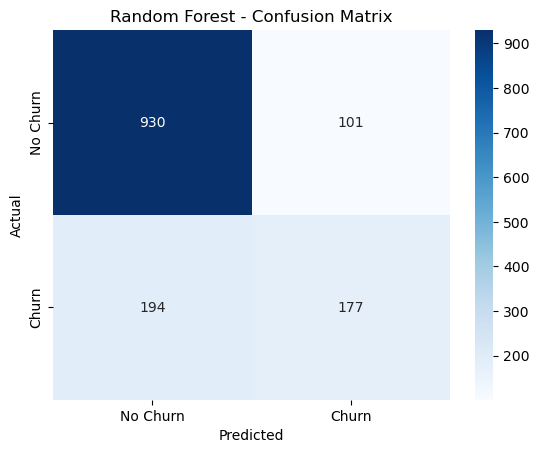

In [56]:
# Visualize Random Forest Confusion Matrix

# Create heatmap
sns.heatmap(
    cm_forest,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

# Add title and labels
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Display chart
plt.show()

In [57]:
# Check Random Forest for Overfitting

# Calculate training accuracy
forest_train_accuracy = random_forest_model.score(
    X_train,
    y_train
)

# Calculate testing accuracy
forest_test_accuracy = random_forest_model.score(
    X_test,
    y_test
)

print(
    "Training Accuracy:",
    round(forest_train_accuracy * 100, 2),
    "%"
)

print(
    "Testing Accuracy:",
    round(forest_test_accuracy * 100, 2),
    "%"
)

Training Accuracy: 99.8 %
Testing Accuracy: 78.96 %


Compare All Three Models

In [58]:
# Compare Model Accuracies

# Create a DataFrame containing model results
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "Accuracy": [
        accuracy * 100,
        tree_accuracy * 100,
        forest_accuracy * 100
    ]
})

# Round accuracy values
model_comparison["Accuracy"] = model_comparison["Accuracy"].round(2)

# Display comparison
model_comparison

,Model,Accuracy
0,Logistic Regression,80.88
1,Decision Tree,72.68
2,Random Forest,78.96


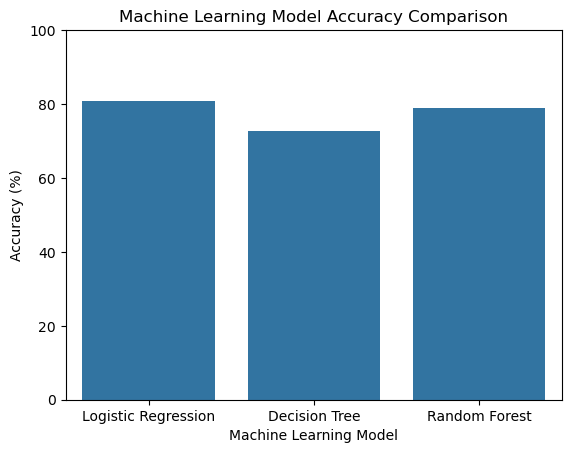

In [59]:
# Visualize Model Accuracy Comparison

# Create bar plot
sns.barplot(
    x="Model",
    y="Accuracy",
    data=model_comparison
)

# Add title and labels
plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

# Set y-axis limit
plt.ylim(0, 100)

# Display chart
plt.show()

In [60]:
# Compare Model Performance Metrics

# Import required metrics
from sklearn.metrics import precision_score, recall_score, f1_score

# Create model performance comparison
performance_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_forest)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_forest)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_forest)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_forest)
    ]
})

# Round values
performance_comparison = performance_comparison.round(3)

# Display results
performance_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.809,0.673,0.539,0.599
1,Decision Tree,0.727,0.484,0.477,0.480
2,Random Forest,0.790,0.637,0.477,0.545


Create Balanced Logistic Regression

In [61]:
# Logistic Regression with Balanced Classes

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
# Give more importance to the minority class (Churn = Yes)
balanced_model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

# Train the model
balanced_model.fit(X_train_scaled, y_train)

print("Balanced Logistic Regression Model Trained Successfully!")

Balanced Logistic Regression Model Trained Successfully!


In [62]:
# Predict Using Balanced Logistic Regression

# Predict churn on test data
y_pred_balanced = balanced_model.predict(X_test_scaled)

print("First 10 Predictions:")
print(y_pred_balanced[:10])

First 10 Predictions:
[1 0 0 1 0 1 0 0 0 0]


In [63]:
# Calculate Accuracy

balanced_accuracy = accuracy_score(
    y_test,
    y_pred_balanced
)

print("Balanced Model Accuracy:", balanced_accuracy)

print(
    "Accuracy Percentage:",
    round(balanced_accuracy * 100,2),
    "%"
)

Balanced Model Accuracy: 0.7432239657631954
Accuracy Percentage: 74.32 %


In [64]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred_balanced,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1031
       Churn       0.51      0.78      0.62       371

    accuracy                           0.74      1402
   macro avg       0.71      0.75      0.71      1402
weighted avg       0.80      0.74      0.76      1402



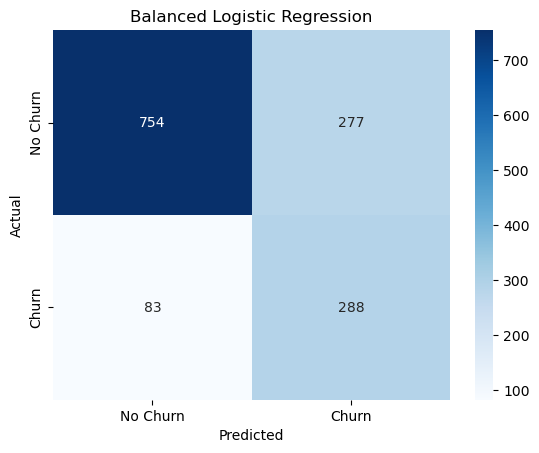

In [65]:
# Balanced Model Confusion Matrix

cm_balanced = confusion_matrix(
    y_test,
    y_pred_balanced
)

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.title("Balanced Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SMOTE (Synthetic Minority Oversampling Technique)

In [66]:
!pip install imbalanced-learn

In [67]:
# Apply SMOTE to Balance Training Data

# Import SMOTE
from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE only on the training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Display class distribution before and after SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Churn
0    4122
1    1486
Name: count, dtype: int64

After SMOTE:
Churn
0    4122
1    4122
Name: count, dtype: int64


In [68]:
# Train Logistic Regression on SMOTE Data

# Create Logistic Regression model
smote_model = LogisticRegression(
    random_state=42
)

# Train the model
smote_model.fit(
    X_train_smote,
    y_train_smote
)

print("SMOTE Logistic Regression Model Trained Successfully!")

SMOTE Logistic Regression Model Trained Successfully!


In [69]:
# Predict Using SMOTE Model

# Predict test data
y_pred_smote = smote_model.predict(
    X_test_scaled
)

print("First 10 Predictions:")
print(y_pred_smote[:10])

First 10 Predictions:
[1 0 0 1 0 1 0 0 1 0]


In [70]:
# Calculate Accuracy

smote_accuracy = accuracy_score(
    y_test,
    y_pred_smote
)

print(
    "SMOTE Model Accuracy:",
    round(smote_accuracy * 100,2),
    "%"
)

SMOTE Model Accuracy: 74.61 %


In [71]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred_smote,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1031
       Churn       0.51      0.77      0.62       371

    accuracy                           0.75      1402
   macro avg       0.71      0.75      0.71      1402
weighted avg       0.80      0.75      0.76      1402



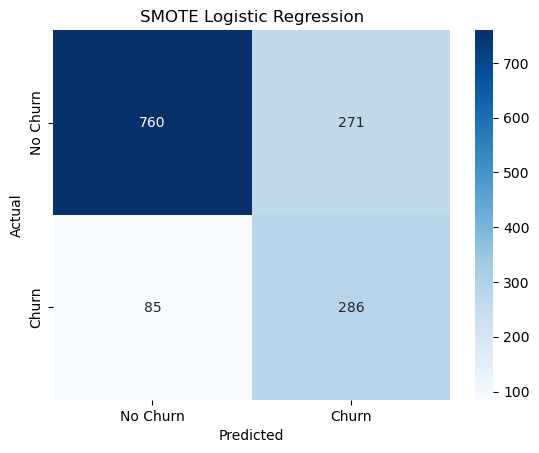

In [72]:
# SMOTE Confusion Matrix

cm_smote = confusion_matrix(
    y_test,
    y_pred_smote
)

sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.title("SMOTE Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Hyperparameter Tuning

In [74]:
# Hyperparameter Tuning using GridSearchCV

from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

# Create Logistic Regression model
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

# Train
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Recall Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

Best Recall Score:
0.8122613156170203


In [75]:
# Best Logistic Regression Model

best_model = grid_search.best_estimator_

print(best_model)

LogisticRegression(C=10, class_weight='balanced', random_state=42)


In [76]:
# Predict Using Best Model

y_pred_best = best_model.predict(X_test_scaled)

In [77]:
# Evaluate Best Model

print(classification_report(
    y_test,
    y_pred_best,
    target_names=["No Churn","Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1031
       Churn       0.51      0.78      0.61       371

    accuracy                           0.74      1402
   macro avg       0.70      0.75      0.71      1402
weighted avg       0.80      0.74      0.76      1402



In [78]:
# Import Joblib

# Joblib is used to save and load trained machine learning models
import joblib

In [79]:
# Save the Trained Model

# Save the balanced logistic regression model
joblib.dump(balanced_model, "customer_churn_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [80]:
# Save the Standard Scaler

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved Successfully!")

Scaler Saved Successfully!


In [81]:
# Load Saved Model

# Load saved model
loaded_model = joblib.load("customer_churn_model.pkl")

# Load saved scaler
loaded_scaler = joblib.load("scaler.pkl")

print("Model Loaded Successfully!")
print(loaded_model)

Model Loaded Successfully!
LogisticRegression(class_weight='balanced', random_state=42)


In [82]:
# Import Required Libraries for Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import joblib

In [83]:
# Reload Original Dataset

# Load original dataset
df_pipeline = pd.read_csv("Telco-Customer-Churn.csv")

# Convert TotalCharges to numeric
df_pipeline["TotalCharges"] = pd.to_numeric(
    df_pipeline["TotalCharges"],
    errors="coerce"
)

# Remove missing values
df_pipeline.dropna(inplace=True)

# Remove customerID
df_pipeline.drop("customerID", axis=1, inplace=True)

# Convert target variable
df_pipeline["Churn"] = df_pipeline["Churn"].map({
    "No":0,
    "Yes":1
})

# Display first rows
df_pipeline.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [84]:
# Features and Target

X = df_pipeline.drop("Churn", axis=1)

y = df_pipeline["Churn"]

In [85]:
# Separate Numeric and Categorical Columns

categorical_features = X.select_dtypes(include="object").columns

numerical_features = X.select_dtypes(exclude="object").columns

print(categorical_features)

print(numerical_features)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [86]:
# Create Preprocessing Pipeline

preprocessor = ColumnTransformer(

    transformers=[

        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        ),

        (
            "num",
            StandardScaler(),
            numerical_features
        )

    ]

)

In [87]:
# Create Complete Machine Learning Pipeline

pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",
         LogisticRegression(
             class_weight="balanced",
             C=10,
             random_state=42
         ))

    ]

)

pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [90]:
# Train Pipeline

pipeline.fit(X, y)

joblib.dump(
    pipeline,
    "churn_pipeline.pkl"
)

print("Pipeline Trained Successfully!")

Pipeline Trained Successfully!


In [89]:
# Save Complete Pipeline

joblib.dump(
    pipeline,
    "churn_pipeline.pkl"
)

print("Pipeline Saved Successfully!")

Pipeline Saved Successfully!
